# Example: Adaptive Drug Dosing as a Markov Decision Process
In this example, we treat a course of chemotherapy as a sequential decision problem and solve it with reinforcement learning. Here is the scenario:

__Scenario__: A patient is treated over a series of cycles. At each cycle, we choose a drug dose. The drug shrinks the tumor but also accumulates toxicity (side effects). A high dose every cycle drives toxicity to a lethal level before the tumor is gone, while never dosing lets the tumor persist. The challenge is to learn _when_ and _how much_ to dose.

This uses the same machinery as the [lava-world example](CHEME-153-M4-Example-LavaWorldProblem-Q-Learning-Watch-Demo.ipynb), but with a clinical state in place of a position on a grid: the state is the patient's tumor burden and toxicity, the actions are drug doses, toxic death plays the role of the lava pit, and a cure plays the role of the charging station.

> __Learning Objectives:__
>
> After completing this activity, students will be able to:
>
> * __Formulate a treatment as a Markov decision process:__ Encode tumor burden and toxicity as a state, dose as an action, and pharmacological dynamics as transitions, where each action changes the next state.
> * __Compare model-based and model-free solutions:__ Compute the exact optimal policy by value iteration when the dynamics are known, then learn a policy by model-free Q-learning, and benchmark the two.
> * __Interpret the learned dosing policy:__ Read the pulse-and-rest strategy that emerges, in which the agent doses to shrink the tumor and then rests to let toxicity clear.

Let's get started!
___

## The Markov Decision Process
We describe the patient with two state variables on a grid: the tumor burden $T\in[0,1]$ and the accumulated toxicity $Z\in[0,1]$. Each cycle the agent administers a dose $u\in\{0, \tfrac{1}{3}, \tfrac{2}{3}, 1\}$ (none, low, medium, high). The state then evolves according to two difference equations:
$$
\begin{align*}
T_{t+1} &= T_{t} + \underbrace{g\,T_{t}\,(1 - T_{t})}_{\text{logistic growth}} - \underbrace{k\,u_{t}\,T_{t}}_{\text{dose-dependent kill}}\\
Z_{t+1} &= Z_{t} + \underbrace{a\,u_{t}}_{\text{toxicity loading}} - \underbrace{c\,Z_{t}}_{\text{first-order clearance}}
\end{align*}
$$
The continuous next state is snapped to the nearest grid cell, which makes this a finite Markov decision process. Two states are absorbing:

* __Cure__ (a positive terminal reward) when $T \leq T_{\text{cure}}$.
* __Toxic death__ (a negative terminal reward) when $Z \geq Z_{\text{lethal}}$.

At every non-absorbing step the agent receives a small penalty that discourages large tumors, high toxicity, and unnecessary dosing:
$$
r(s,a) = -\left(w_{T}\,T_{t+1} + w_{Z}\,Z_{t+1} + \text{cost}\cdot u_{t}\right)
$$
Because dosing now raises toxicity _later_, the agent must balance shrinking the tumor against staying below the lethal toxicity threshold. This is a genuinely sequential decision problem, which is exactly where reinforcement learning is useful.
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-150-eCornell-Repository/CHEME-150-eCornell-Repository/courses/CHEME-153/module-4`


This example uses local source files for the environment and the solvers: the model types are defined in [`src/Types.jl`](src/Types.jl), their constructors in [`src/Factory.jl`](src/Factory.jl), and the dynamics `world(...)`, the `solve(...)` routines (value iteration and Q-learning), `policy(...)`, and `simulate(...)` in [`src/Compute.jl`](src/Compute.jl). These are loaded for you by `Include.jl`.

___

## Task 1: Build the dosing environment
We encode the environment with the [`MyAdaptiveDosingModel` type](src/Types.jl), which stores the state grid, the dose actions, the dynamics parameters $(g, k, a, c)$, the absorbing thresholds, and the reward parameters. The `build(...)` method also constructs the maps between grid cells $(i_T, i_Z)$ and integer state indices, exactly like the grid-world model.

> __Parameters:__ We use a $41\times41$ grid (`nlevels = 41`). The tumor grows at rate `g` and is killed with efficacy `k` at full dose; toxicity loads at rate `a` per unit dose and clears at fraction `c` per cycle. The patient is cured at `Tcure` and dies at `Zlethal`.

Build the environment and save it in the `env::MyAdaptiveDosingModel` variable:

In [2]:
env = build(MyAdaptiveDosingModel, (
    nlevels = 41,                   # 41 x 41 state grid (T, Z in 0, 0.025, ..., 1)
    doses   = [0.0, 1/3, 2/3, 1.0], # none, low, medium, high

    g = 0.15, # tumor logistic growth rate
    k = 0.35, # tumor kill efficacy at full dose
    a = 0.50, # toxicity loading per unit dose
    c = 0.35, # toxicity clearance fraction per cycle

    Tcure   = 0.10, # cured if tumor burden <= 0.10
    Zlethal = 0.90, # toxic death if toxicity >= 0.90

    wT = 1.0, wZ = 1.0, cost = 0.10, # step-penalty weights
    Rcure = 60.0, Rdead = -60.0      # terminal rewards
));

nstates = env.nlevels^2;     # number of grid states
ndoses  = length(env.doses); # number of dose actions

### Why a fixed dose fails
Before learning a policy, let's see what happens under the four _constant_ dose schedules, starting from a large tumor and no toxicity, $(T_0, Z_0) = (0.90, 0.0)$. We roll each schedule out with `simulate(...)` and report the outcome.

> A constant policy is a vector that returns the same dose in every state. The `simulate(...)` function rolls the policy out until the patient is cured, dies, or we reach the step limit.

Let's run the four baselines:

In [3]:
let
    s0 = stateindex(env, 0.90, 0.0) # clinical start: big tumor, no toxicity
    df = DataFrame()
    for (name, aidx) in [("none",1), ("low",2), ("medium",3), ("high",4)]
        r = simulate(env, fill(aidx, nstates), s0)
        push!(df, (schedule=name, dose=env.doses[aidx], outcome=String(r.outcome), cycles=r.steps))
    end
    pretty_table(df; backend=:text, table_format=TextTableFormat(borders=text_table_borders__compact))
end

 ---------- ---------- --------- --------
  schedule       dose   outcome   cycles 
    String    Float64    String    Int64 
 ---------- ---------- --------- --------
      none        0.0   timeout      100
       low   0.333333   timeout      100
    medium   0.666667      dead        7
      high        1.0      dead        3
 ---------- ---------- --------- --------


No fixed dose works: none and low never cure the tumor, while medium and high kill the patient with toxicity. The agent needs a _policy_ that changes the dose based on the state.
___

## Task 2: The exact optimum by value iteration
Because we _know_ the dynamics (they are encoded in `world(...)`), we can compute the optimal policy exactly with __value iteration__. Calling `solve(...)` on the environment returns the optimal action-value table $Q^{\star}$; the optimal policy is then `policy(Qstar)`.

> Value iteration repeatedly applies the Bellman backup $U(s)\gets\max_{a}\left[r(s,a) + \gamma\,U(s')\right]$ until the value function converges. Since the next state $s'$ is deterministic here, each backup is a single lookup. This is our ground-truth benchmark.

Compute the optimal action-value table and the optimal policy:

In [4]:
Qstar  = solve(env; γ = 0.95);  # value iteration (model-based)
π_star = policy(Qstar);         # optimal dosing policy

Let's roll out the optimal policy from the clinical start $(T_0, Z_0) = (0.90, 0.0)$ and look at the dose it administers each cycle:

In [5]:
vi = simulate(env, π_star, stateindex(env, 0.90, 0.0));
println("Outcome: ", vi.outcome, " in ", vi.steps, " cycles")
println("Dose schedule: ", round.(vi.dose, digits=2))

Outcome: cured in 13 cycles
Dose schedule: [1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.67, 0.33, 0.67, 0.67, 0.67, 0.0]


The optimal policy _pulses_: it gives high doses to knock the tumor down, then rests (dose 0) to let toxicity clear before the next pulse, finishing with medium doses. No constant schedule could do this.
___

## Task 3: Learning the policy from experience (Q-learning)
Now suppose we do _not_ know the dynamics. The agent can only interact with the environment, observing sampled transitions $(s, a, r, s')$, and must learn a policy from experience. This is __model-free Q-learning__.

We build a [`MyQLearningAgentModel`](src/Types.jl), then `solve(...)` it against the environment. Each episode starts from a random patient state and runs until cure, death, or a step limit; the agent updates its $Q$ table with a temporal-difference rule using a $1/N(s,a)$ learning-rate schedule, which satisfies the convergence conditions from the lecture.

> __Note:__ The agent never uses `world(...)` to plan ahead; it only receives sampled transitions from it, exactly as it would from real treatment data.

Build and train the agent:

In [6]:
agent = build(MyQLearningAgentModel, (
    states  = collect(1:nstates),
    actions = collect(1:ndoses),
    α = 0.1,                    # nominal rate (the solver anneals as 1/N(s,a))
    γ = 0.95,                   # discount factor (matches value iteration)
    Q = zeros(nstates, ndoses)  # initialize the Q-table to zeros
));

agent = solve(agent, env; episodes = 200_000, maxsteps = 80); # model-free training
π_q = policy(agent.Q);  # learned dosing policy

Let's roll out the learned policy from the same clinical start:

In [7]:
ql = simulate(env, π_q, stateindex(env, 0.90, 0.0));
println("Outcome: ", ql.outcome, " in ", ql.steps, " cycles")
println("Dose schedule: ", round.(ql.dose, digits=2))

Outcome: cured in 13 cycles
Dose schedule: [1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.67, 0.33, 0.67, 0.67, 0.67, 0.0]


___

## Task 4: Benchmarking the learned policy against the optimum
How close did model-free Q-learning get to the exact value-iteration optimum? We compare the two policies on the states the optimal policy actually visits (the clinically relevant region), and we check that both cure the patient from a range of starting tumor burdens.

> Most off-path states are visited rarely during learning and often have several near-equally-good doses (ties), so we focus the comparison on reachable states and on the realized treatment outcomes.

Compare the policies:

In [8]:
let
    # states reachable from a range of starts under the optimal policy -
    reach = Set{Int}()
    for T0 in 0.10:0.05:0.95
        s = stateindex(env, T0, 0.0)
        for _ in 1:200
            isterminal(env, s) && break
            push!(reach, s)
            (s, _) = world(env, s, π_star[s])
        end
    end
    reach = collect(reach)
    agreement = count(s -> π_q[s] == π_star[s], reach) / length(reach)
    println("Policy agreement on ", length(reach), " reachable states: ",
        round(100*agreement, digits=1), "%\n")

    # outcomes from several starting tumor burdens -
    df = DataFrame()
    for T0 in [0.30, 0.50, 0.70, 0.90]
        s = stateindex(env, T0, 0.0)
        a = simulate(env, π_star, s)
        b = simulate(env, π_q,    s)
        push!(df, (start_T = T0,
            VI_outcome = String(a.outcome), VI_cycles = a.steps,
            Q_outcome  = String(b.outcome), Q_cycles  = b.steps))
    end
    pretty_table(df; backend=:text, table_format=TextTableFormat(borders=text_table_borders__compact))
end

Policy agreement on 71 reachable states: 74.6%

 --------- ------------ ----------- ----------- ----------
  start_T   VI_outcome   VI_cycles   Q_outcome   Q_cycles 
  Float64       String       Int64      String      Int64 
 --------- ------------ ----------- ----------- ----------
      0.3        cured           6       cured          7
      0.5        cured           9       cured          9
      0.7        cured          12       cured         13
      0.9        cured          13       cured         13
 --------- ------------ ----------- ----------- ----------


### Visualizing the policy and a treatment
Finally, let's visualize the optimal policy as a heatmap over the $(T, Z)$ state grid (the dose the agent administers in each patient state) and overlay the treatment trajectory from the clinical start. The path traces the pulse-and-rest strategy: dosing drives the state toward cure (left) while toxicity rises toward the lethal line, then resting lets toxicity fall before the next pulse.

`Unhide` the code block below to see how we build the plot:

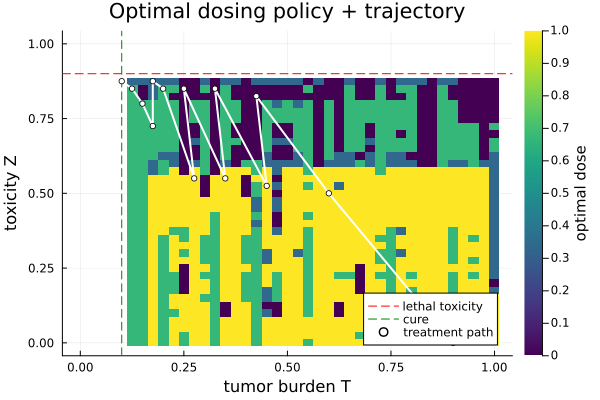

In [9]:
let
    Tgrid = [(i-1)*env.step for i in 1:env.nlevels]
    Zgrid = [(j-1)*env.step for j in 1:env.nlevels]

    # optimal dose at each (T, Z); NaN over absorbing cells -
    M = fill(NaN, env.nlevels, env.nlevels)
    for iT in 1:env.nlevels, iZ in 1:env.nlevels
        s = env.states[(iT, iZ)]
        isterminal(env, s) == false && (M[iZ, iT] = env.doses[π_star[s]])
    end

    p = heatmap(Tgrid, Zgrid, M; c=:viridis, colorbar_title="optimal dose",
        xlabel="tumor burden T", ylabel="toxicity Z", title="Optimal dosing policy + trajectory")
    hline!(p, [env.Zlethal], color=:red,   ls=:dash, label="lethal toxicity")
    vline!(p, [env.Tcure],   color=:green, ls=:dash, label="cure")
    plot!(p, vi.T, vi.Z; lw=2, c=:white, marker=:circle, ms=3, label="treatment path")
    p
end

We can also view the same treatment as time series: the tumor burden falls in steps while toxicity oscillates in a sawtooth just below the lethal line, driven by the pulsed dose.

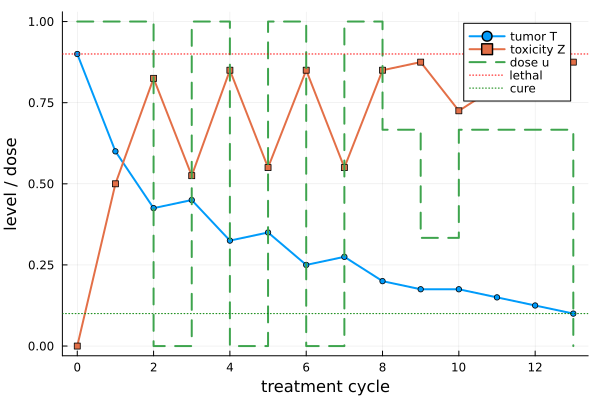

In [10]:
let
    cycles = 0:(length(vi.T)-1)
    p = plot(cycles, vi.T; lw=2, marker=:circle, ms=3, label="tumor T",
        xlabel="treatment cycle", ylabel="level / dose")
    plot!(p, cycles, vi.Z; lw=2, marker=:square, ms=3, label="toxicity Z")
    plot!(p, cycles, vi.dose; seriestype=:steppost, lw=2, ls=:dash, label="dose u")
    hline!(p, [env.Zlethal]; color=:red,   ls=:dot, label="lethal")
    hline!(p, [env.Tcure];   color=:green, ls=:dot, label="cure")
    p
end

___

## Summary
In this activity, we framed a course of drug treatment as a Markov decision process and solved it two ways: exactly with value iteration (using the known dynamics) and model-free with Q-learning (using only sampled experience).

> __Key Takeaways:__
>
> * __Sequential structure makes it a reinforcement learning problem:__ Because a dose now raises toxicity later, the action changes the future state, so the optimal policy must sequence doses over time. This is the property that makes reinforcement learning the right tool.
> * __Pulse-and-rest emerges from optimization:__ No constant dose works, since high doses are lethal and low doses never cure. Both value iteration and Q-learning discover a pulse-and-rest schedule that shrinks the tumor while keeping toxicity below the lethal threshold.
> * __Model-free learning recovers the optimum:__ With the dynamics hidden, Q-learning learns a policy that cures the patient in nearly the same number of cycles as the exact value-iteration optimum, which we confirmed by benchmarking the two policies directly.

When the dynamics are known, value iteration gives the exact optimal policy; when they are not, model-free reinforcement learning can recover it from experience alone.
___